This extraction and fit assumes using the mass method.


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


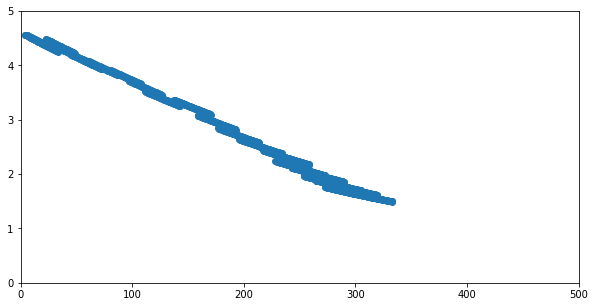

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize
import scipy.stats
import pandas as pd
import bisect

def fishplate_function(x, *params):
    return params[0]*x + params[1]
initial_values = np.array([5, 10]) # Initial guess for fit parameters

def chi_squared(model_params, model, x_data, y_data, y_err):
    return np.sum(((y_data - model(x_data, *model_params))/y_err)**2)

def theoretical(x, A, k):
    return A*(1 - np.exp(k/x))

print("This extraction and fit assumes using the mass method.")
x = 0

h0s = []
files = []
initial_values = [-0.001, 1, 1]
t_xvalues = np.array([])
t_yvalues = np.array([])
TOTAL_X = []
TOTAL_Y = []
t_at_next_h_0 = 0 
insert_position = 0

testx = []
testy = []


#while x != 'f':
#    x = input('List your datafiles IN ORDER (including extentions), press return \n after each file name is entered. \n Type "f", then press return to finish.')
#    files.append(x)
#    if x == 'restart':
#        files = []
#    if x == 'remove':
#        files = files[:-2]
#        print(files)



#files = files[:-1]
dat = True #KEEP FOR NOW, used later to check what filetype everything is

#######
h0s = [114,113,112,108, 105, 102, 98, 93, 88,84,77,71,66,61,56,53,49,47,44,42]
rho = 1000
Qy_errors = 0.001
files = ['mm114DD1.dat', 'mm113DD1.dat', 'mm112DD2.dat','mm108DD1.dat', 'mm105DD1.dat','mm102DD1.dat', 'mm98DD1.dat', 'mm93DD1.dat', 'mm88DD1.dat', 'mm84DD1.dat', 'mm77DD1.dat','mm71DD1.dat', 'mm66DD1.dat', 'mm61DD1.dat', 'mm56DD1.dat', 'mm53DD1.dat', 'mm49DD1.dat', 'mm47DD1.dat', 'mm44DD1.dat', 'mm42DD1.dat']
area = 0.2**2
counter = 0
########


extract = []
for i in range(len(files)):
    extract.append(np.loadtxt(files[i], unpack=True, dtype=np.float64))

#h0s = pd.read_csv(input('Type the name of the CSV file with values of h_0 in the first column. Include the file extention.'))

#rho = input('Type the value of the density of water in kg m^-3 found for this trial.')
#Qy_errors = input('Type the error in mass (in grams) found for this trial.')

m_0B = 0
#sets up to begin stitching together the data sets 
t_xvalues = np.array(extract[0][0]/1000) - (extract[0][0][0]/1000)*np.ones(len(extract[0][0])) #first (x values) decay curve in standard units 
t_yvalues = np.array(extract[0][1])
m_0 = area * h0s[0]/1000 * rho
m_0_arr = np.array([m_0]*len(t_yvalues))
t_yvalues = m_0_arr - (t_yvalues/1000)

y_values = m_0_arr - (t_yvalues/1000)#first (y values) decay curve in standard units 


for k in range(len(extract) -1 ): #starts by comparing first to second. -1 as what to compare the last one to... 
    x_values = extract[k][0] # x values centered at 0 (NO SHIFT)
    y_extract = extract[k][1]
    m_0 = area * h0s[k]/1000 * rho
    m_0_arr = np.array([m_0]*len(t_yvalues))
    y_values = m_0_arr - (y_values/1000) #mass decay y values 
    
    y_errors = [Qy_errors]*len(y_values)
    x_values = x_values / 1000

    ######################################
    x_valuesB = extract[k+1][0]
    y_extractB = extract[k+1][1]
    m_0B = area * h0s[k+1]/1000 * rho
    m_0_listB = [m_0]*len(y_extractB)
    m_0_arrB = np.array(m_0_listB)
    y_valuesB = m_0_arrB - (y_extractB/1000)
    y_errorsB = [Qy_errors]*len(y_valuesB)
    x_valuesB = x_valuesB / 1000 
    #######################################
    
    look_in = np.searchsorted(t_xvalues, m_0B) #numerical position of where m_0B would fit in
    if look_in < 2: #makes sure that you actually get a look_in value
        look_in = 2
    look_in_range = [look_in - 2, look_in + 2]
    link_xs = np.array(t_xvalues[look_in_range[0]:look_in_range[-1]])
    link_ys = np.array(t_yvalues[look_in_range[0]:look_in_range[-1]])
    link_y_errors = np.array([Qy_errors] *4)
    degrees_of_freedom = link_xs.size - len(initial_values)
    popt, cov = scipy.optimize.curve_fit(fishplate_function, link_xs, link_ys, sigma=link_y_errors, absolute_sigma=True, p0=initial_values, check_finite=True) 
    gradientA = popt[0]
    interceptA = popt[1]
    t_at_next_h_0 = (m_0B - interceptA)/gradientA
    corr_x_B = np.array(t_at_next_h_0*np.ones(len(x_valuesB)) + np.array(x_valuesB) - (x_valuesB[0]*np.ones(len(x_valuesB))))

    ## change appending method so is ordered##
    for p in range(len(corr_x_B)):
        insert_position = bisect.bisect_left(list(t_xvalues), list(corr_x_B)[p])
        bisect.insort_left(list(t_xvalues), list(corr_x_B)[p])
        np.insert(t_yvalues,insert_position, y_valuesB[p])
        counter +=1
    testx += list(corr_x_B)
    testy += list(y_valuesB)

            
    #for j in range(len(t_xvalues)-1):
        #TOTAL_X += (list(t_xvalues[j+1]))
        #TOTAL_Y += (list(t_yvalues[j+1]))
plt.gca().set_xlim([0,500])
plt.gca().set_ylim([0,5])
plt.scatter(testx,testy)
fig = plt.gcf()
fig.set_size_inches(10, 5)

    

Optimised parameters =  [-3.48766963  2.85056563] 

Covariance matrix = 
 [[2.28682771e-01 3.08996636e-09]
 [3.08996636e-09 4.66617981e-14]]


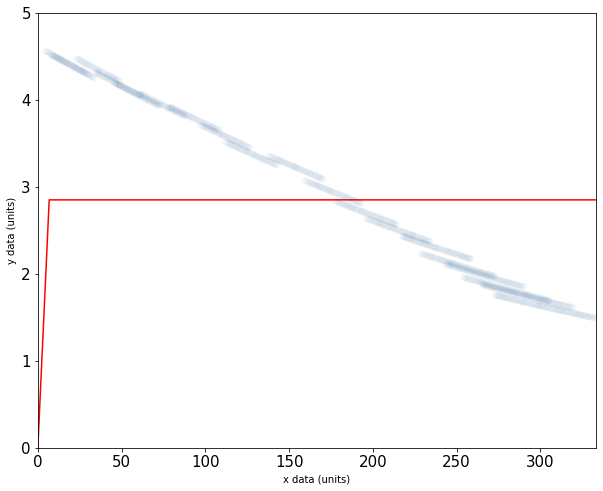

chi^2_min = 20376579418778.918
reduced chi^2 = 9508436499.663517
P(chi^2_min, DoF) = 0.0
best fit slope = -3.4876696349374603 units?
best fit intercept = 2.850565633437624 units?
optimised parameter[0] = (-3.4876696349374603 +/- 0.47820787401655157) units
optimised parameter[1] = (2.850565633437624 +/- 2.1601342107703652e-07) units


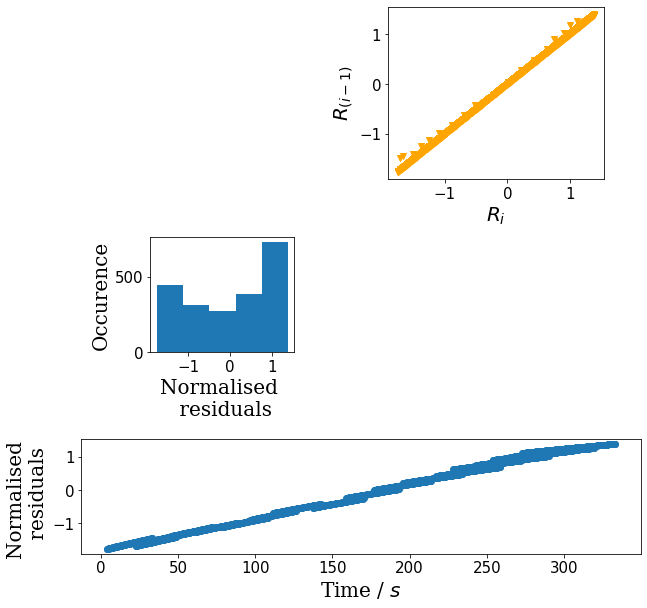

In [2]:
import numpy 

x_values = numpy.array(testx)
y_values = numpy.array(testy)
y_errors = numpy.array([0.00001] * len(y_values))

ff = 'serif'
fs = 20
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
plt.rcParams['figure.figsize'] = [10,8]
fig, ax = plt.subplots()

def model_function(x, *params):
    return params[1]*(1 - numpy.exp(params[0]*x))
####DO NOT CHANGE THESE####
initial_values = numpy.array([-0.0013, 4.5]) # Initial guess for fit parameters
####DO NOT CHANGE THESE####
def chi_squared(model_params, model, x_data, y_data, y_err):
    return numpy.sum(((y_data - model(x_data, *model_params))/y_err)**2) # Note the `*model_params' here!

degrees_of_freedom = x_values.size - initial_values.size

popt, cov = scipy.optimize.curve_fit(model_function, # function to fit
                                     x_values, # x data
                                     y_values, # y data
                                     sigma=y_errors, # array of error bars for the fit
                                     absolute_sigma=True, # errors bars DO represent 1 std error
                                     p0=initial_values, # starting point for fit
                                     check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

print('Optimised parameters = ', popt, '\n')
print('Covariance matrix = \n', cov)

plt.errorbar(x_values, 
             y_values, 
             yerr=y_errors, 
             marker='o', 
             linestyle='None', alpha =0.01)

plt.xlabel('x data (units)') # Axis labels
plt.ylabel('y data (units)')

modelx = np.linspace(0,max(x_values))
# Generate best fit using model function and best fit parameters, and add to plot
plt.plot(modelx, 
         model_function(modelx, *popt), 
         color='r')


plt.gca().set_xlim([0,max(x_values)])
plt.gca().set_ylim([0,5])
plt.show()

residuals = (model_function(x_values, *popt) - y_values) / numpy.std(y_values) #it is NORMALISED 
plt.figure(1).add_axes((0.124,-0.1,0.7769,0.2))
plt.scatter(x_values, residuals)
plt.xlabel('Time / $s$', family = ff, fontsize = fs)
plt.ylabel('Normalised \n residuals', family = ff, fontsize = fs)


#lag plot 
plt.figure(1).add_axes((0.55,0.55,0.3,0.3))

R_i_minus = residuals[:-1]
R_i = residuals[1:]



plt.scatter(R_i, R_i_minus, marker = 'v', color = 'orange')
plt.ylabel('$R_{(i-1)}$', family = ff, fontsize = fs)
plt.xlabel('$R_{i}$', family = ff, fontsize = fs)

plt.figure(1).add_axes((0.22,0.25,0.2,0.2))
plt.hist(residuals, bins = 5)
plt.xlabel('Normalised \n residuals', family = ff, fontsize = fs)
plt.ylabel('Occurence', family = ff, fontsize = fs)


chi_squared_min = chi_squared(popt, model_function, x_values, y_values, y_errors)
print('chi^2_min = {}'.format(chi_squared_min))
print('reduced chi^2 = {}'.format(chi_squared_min/degrees_of_freedom))
print('P(chi^2_min, DoF) = {}'.format(scipy.stats.chi2.sf(chi_squared_min, degrees_of_freedom)))

print('best fit slope = {} units?'.format(popt[0]))
print('best fit intercept = {} units?'.format(popt[1]))

popt_errs = numpy.sqrt(numpy.diag(cov))
for i, (val, err) in enumerate(zip(popt, popt_errs)):
    print('optimised parameter[{}] = ({} +/- {}) units'.format(i, val, err))
    

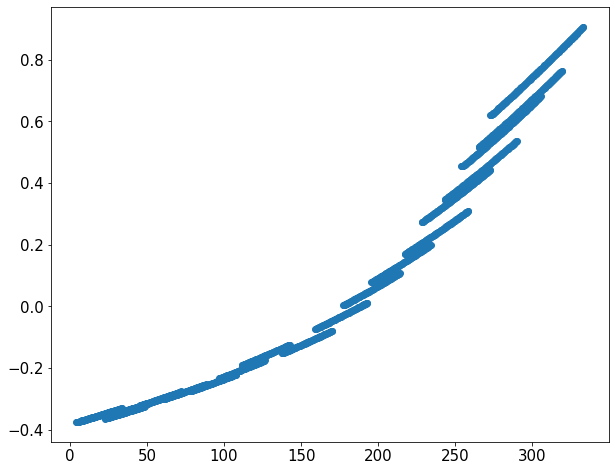

In [3]:
#residuals 

residuals = (model_function(x_values, *popt) - y_values) / y_values

plt.scatter(x_values, residuals)

